In [1]:
import pandas as pd

In [2]:
dataframe = pd.read_csv("daily-total-female-births-CA.csv", header=0)

In [3]:
### First five records
dataframe.head()

,date,births
0,1959-01-01,35
1,1959-01-02,32
2,1959-01-03,30
3,1959-01-04,31
4,1959-01-05,44


In [4]:
# Data type
dataframe.dtypes

date        str
births    int64
dtype: object

In [5]:
# loading data with parse_dates
df2 = pd.read_csv("daily-total-female-births-CA.csv", header=0, parse_dates=[0])

In [6]:
df2.head()

,date,births
0,1959-01-01,35
1,1959-01-02,32
2,1959-01-03,30
3,1959-01-04,31
4,1959-01-05,44


In [7]:
df2.dtypes

date      datetime64[us]
births             int64
dtype: object

# Note
dateparse = lambda x: pd.datetime.strptime(x, "%Y-%m-%d")
df = pd.read_csv(........, parse_dates=['Date'], date_parser=dateparse)

# Loading Data as a series

In [8]:
series = pd.read_csv("daily-total-female-births-CA.csv", header=0, parse_dates=[0], index_col=0)

In [9]:
# first five records
series.head()

,births
date,
1959-01-01,35
1959-01-02,32
1959-01-03,30
1959-01-04,31
1959-01-05,44


### Exploring Time Series Data

In [10]:
# Size
series.size

365

In [11]:
series.shape

(365, 1)

### Querying by time

In [12]:
print(series.loc['1959-01-01'])

births    35
Name: 1959-01-01 00:00:00, dtype: int64


In [13]:
df2[(df2['date'] > '1959-01-01') & (df2['date'] <= '1959-01-31')]

,date,births
1,1959-01-02,32
2,1959-01-03,30
3,1959-01-04,31
4,1959-01-05,44
5,1959-01-06,29
6,1959-01-07,45
7,1959-01-08,43
8,1959-01-09,38
9,1959-01-10,27
10,1959-01-11,38


### Descriptive statistics

In [14]:
series.describe()

,births
count,365.000000
mean,41.980822
std,7.348257
min,23.000000
25%,37.000000
50%,42.000000
75%,46.000000
max,73.000000


In [15]:
df2.describe()

,date,births
count,365,365.000000
mean,1959-07-02 00:00:00,41.980822
min,1959-01-01 00:00:00,23.000000
25%,1959-04-02 00:00:00,37.000000
50%,1959-07-02 00:00:00,42.000000
75%,1959-10-01 00:00:00,46.000000
max,1959-12-31 00:00:00,73.000000
std,NaN,7.348257


### Data type

In [16]:
dataframe['date'].dtype

<StringDtype(storage='python', na_value=nan)>

## Time Series - Data Visualization

In [17]:
from matplotlib import pyplot as plt
%matplotlib inline

In [18]:
Dataviz_df = df2.copy()
Dataviz_df.head(10)

,date,births
0,1959-01-01,35
1,1959-01-02,32
2,1959-01-03,30
3,1959-01-04,31
4,1959-01-05,44
5,1959-01-06,29
6,1959-01-07,45
7,1959-01-08,43
8,1959-01-09,38
9,1959-01-10,27


<Axes: >

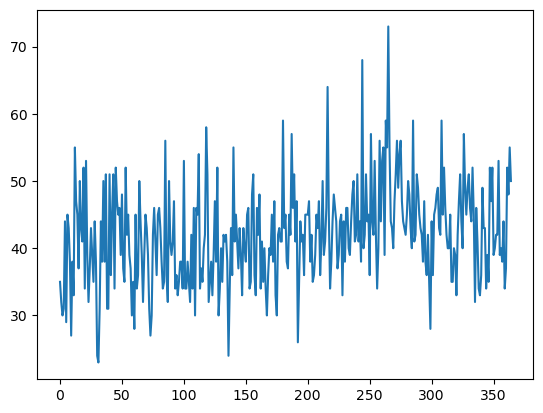

In [19]:
Dataviz_df['births'].plot()

In [20]:
Dataviz_df.index = Dataviz_df['date']

<Axes: xlabel='date'>

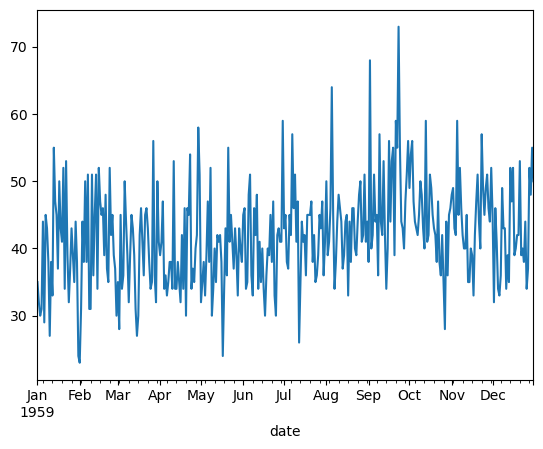

In [21]:
Dataviz_df['births'].plot()

## Zooming In

In [22]:
Dataviz_df2 = Dataviz_df[(Dataviz_df['date'] > '1959-01-01') & (Dataviz_df['date'] <= '1959-01-31')].copy()

In [23]:
Dataviz_df2

,date,births
date,,
1959-01-02,1959-01-02,32
1959-01-03,1959-01-03,30
1959-01-04,1959-01-04,31
1959-01-05,1959-01-05,44
1959-01-06,1959-01-06,29
1959-01-07,1959-01-07,45
1959-01-08,1959-01-08,43
1959-01-09,1959-01-09,38
1959-01-10,1959-01-10,27


<Axes: xlabel='date'>

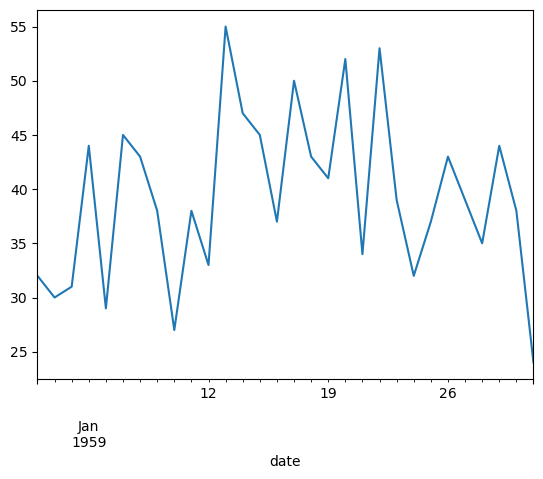

In [24]:
Dataviz_df2['births'].plot()

## Trendline 

In [25]:
import seaborn as sns

<Axes: ylabel='births'>

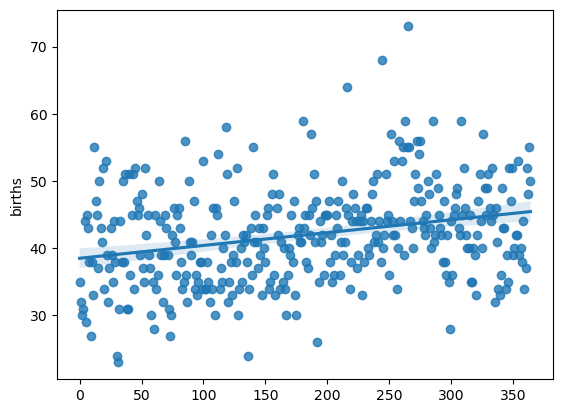

In [26]:
sns.regplot(x=df2.index.values, y=df2['births'])

<Axes: ylabel='births'>

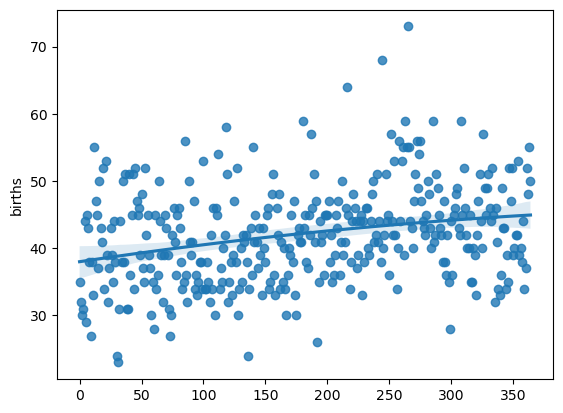

In [27]:
sns.regplot(x=df2.index.values, y=df2['births'], order=2)

In [28]:
miles_df = pd.read_csv("us-airlines-monthly-aircraft-miles-flown.csv", header=0, parse_dates=[0])

In [29]:
miles_df.head()

,Month,MilesMM
0,1963-01-01,6827
1,1963-02-01,6178
2,1963-03-01,7084
3,1963-04-01,8162
4,1963-05-01,8462


<Axes: >

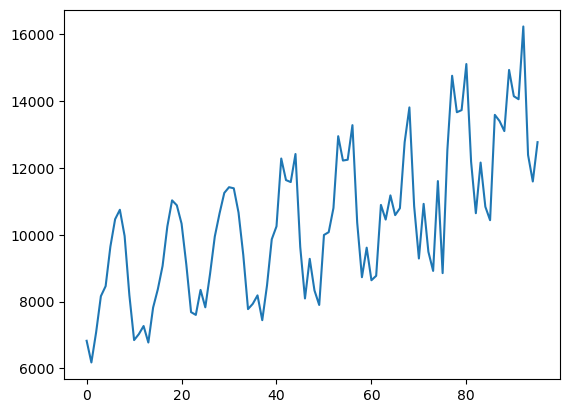

In [30]:
miles_df['MilesMM'].plot()

<Axes: ylabel='MilesMM'>

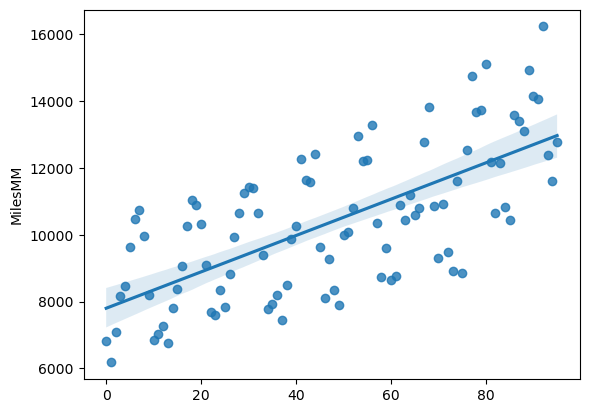

In [31]:
sns.regplot(x=miles_df.index.values, y=miles_df['MilesMM'])

## Removing Seasonality

In [32]:
miles_df['year'] = miles_df['Month'].dt.year

In [33]:
miles_df.head()

,Month,MilesMM,year
0,1963-01-01,6827,1963
1,1963-02-01,6178,1963
2,1963-03-01,7084,1963
3,1963-04-01,8162,1963
4,1963-05-01,8462,1963


In [34]:
miles_df.groupby('year')['MilesMM'].mean()

year
1963     8300.250000
1964     8849.333333
1965     9619.250000
1966     9929.500000
1967    10542.916667
1968    10747.916667
1969    11972.000000
1970    13124.750000
Name: MilesMM, dtype: float64

<Axes: xlabel='year'>

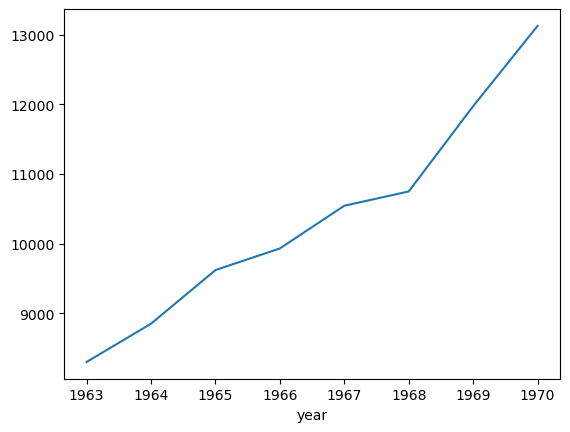

In [35]:
miles_df.groupby('year')['MilesMM'].mean().plot()

## Creating Lag Plots

In [36]:
miles_df['lag1'] = miles_df['MilesMM'].shift(1)

In [37]:
miles_df.head()

,Month,MilesMM,year,lag1
0,1963-01-01,6827,1963,NaN
1,1963-02-01,6178,1963,6827.0
2,1963-03-01,7084,1963,6178.0
3,1963-04-01,8162,1963,7084.0
4,1963-05-01,8462,1963,8162.0


<Axes: xlabel='lag1', ylabel='MilesMM'>

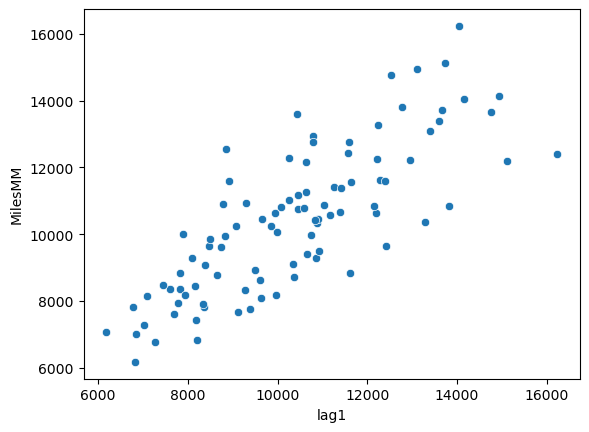

In [38]:
sns.scatterplot(x=miles_df['lag1'], y=miles_df['MilesMM'])

In [39]:
from pandas.plotting import lag_plot

<Axes: xlabel='y(t)', ylabel='y(t + 1)'>

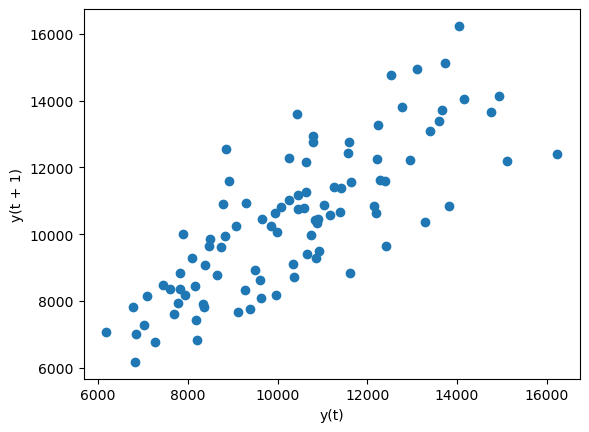

In [40]:
lag_plot(miles_df['MilesMM'])

## Auto-correlation plot

In [41]:
from pandas.plotting import autocorrelation_plot

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

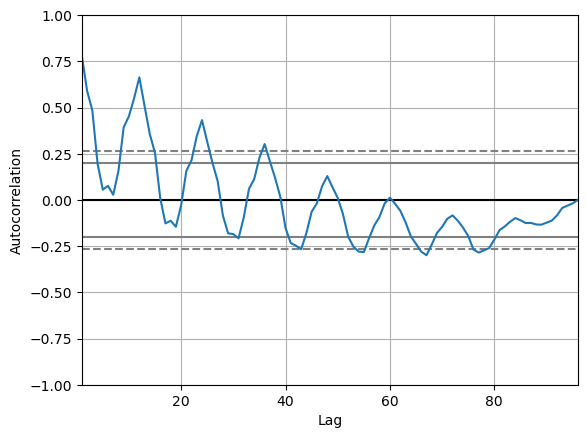

In [42]:
autocorrelation_plot(miles_df['MilesMM'])

## Feature Engineering
- Date time features
- Lag features
- Window features
- Expanding feature

### Date time features

In [43]:
df2.head(5)

,date,births
0,1959-01-01,35
1,1959-01-02,32
2,1959-01-03,30
3,1959-01-04,31
4,1959-01-05,44


In [44]:
features = df2.copy()

In [45]:
features['year'] = features['date'].dt.year
features['month'] = features['date'].dt.month
features['day'] = features['date'].dt.day

In [46]:
features.head()

,date,births,year,month,day
0,1959-01-01,35,1959,1,1
1,1959-01-02,32,1959,1,2
2,1959-01-03,30,1959,1,3
3,1959-01-04,31,1959,1,4
4,1959-01-05,44,1959,1,5


## Lag features

In [47]:
features['lag1'] = features['births'].shift(1)
features['lag2'] = features['births'].shift(365)
features.head()

,date,births,year,month,day,lag1,lag2
0,1959-01-01,35,1959,1,1,NaN,NaN
1,1959-01-02,32,1959,1,2,35.0,NaN
2,1959-01-03,30,1959,1,3,32.0,NaN
3,1959-01-04,31,1959,1,4,30.0,NaN
4,1959-01-05,44,1959,1,5,31.0,NaN


## Window Features

In [48]:
features['Roll_mean'] = df2['births'].rolling(window=2).mean()
features.head() 

,date,births,year,month,day,lag1,lag2,Roll_mean
0,1959-01-01,35,1959,1,1,NaN,NaN,NaN
1,1959-01-02,32,1959,1,2,35.0,NaN,33.5
2,1959-01-03,30,1959,1,3,32.0,NaN,31.0
3,1959-01-04,31,1959,1,4,30.0,NaN,30.5
4,1959-01-05,44,1959,1,5,31.0,NaN,37.5


In [49]:
features['Roll_max'] = df2['births'].rolling(window=3).max()
features.head() 

,date,births,year,month,day,lag1,lag2,Roll_mean,Roll_max
0,1959-01-01,35,1959,1,1,NaN,NaN,NaN,NaN
1,1959-01-02,32,1959,1,2,35.0,NaN,33.5,NaN
2,1959-01-03,30,1959,1,3,32.0,NaN,31.0,35.0
3,1959-01-04,31,1959,1,4,30.0,NaN,30.5,32.0
4,1959-01-05,44,1959,1,5,31.0,NaN,37.5,44.0


## Expanding Features

In [50]:
features['Expand_max'] = df2['births'].expanding().max()
features.head(10)

,date,births,year,month,day,lag1,lag2,Roll_mean,Roll_max,Expand_max
0,1959-01-01,35,1959,1,1,NaN,NaN,NaN,NaN,35.0
1,1959-01-02,32,1959,1,2,35.0,NaN,33.5,NaN,35.0
2,1959-01-03,30,1959,1,3,32.0,NaN,31.0,35.0,35.0
3,1959-01-04,31,1959,1,4,30.0,NaN,30.5,32.0,35.0
4,1959-01-05,44,1959,1,5,31.0,NaN,37.5,44.0,44.0
5,1959-01-06,29,1959,1,6,44.0,NaN,36.5,44.0,44.0
6,1959-01-07,45,1959,1,7,29.0,NaN,37.0,45.0,45.0
7,1959-01-08,43,1959,1,8,45.0,NaN,44.0,45.0,45.0
8,1959-01-09,38,1959,1,9,43.0,NaN,40.5,45.0,45.0
9,1959-01-10,27,1959,1,10,38.0,NaN,32.5,43.0,45.0


## Downsampling and Upsampling

In [51]:
miles_df.head()

,Month,MilesMM,year,lag1
0,1963-01-01,6827,1963,NaN
1,1963-02-01,6178,1963,6827.0
2,1963-03-01,7084,1963,6178.0
3,1963-04-01,8162,1963,7084.0
4,1963-05-01,8462,1963,8162.0


In [52]:
miles_df = pd.read_csv("us-airlines-monthly-aircraft-miles-flown.csv", header=0, parse_dates=[0])
miles_df.head()

,Month,MilesMM
0,1963-01-01,6827
1,1963-02-01,6178
2,1963-03-01,7084
3,1963-04-01,8162
4,1963-05-01,8462


### Downsampling

In [54]:
quarterly_miles_df = miles_df.resample('QE', on='Month').mean() # QE stands for quarter end
quarterly_miles_df.head()

,MilesMM
Month,
1963-03-31,6696.333333
1963-06-30,8756.000000
1963-09-30,10392.333333
1963-12-31,7356.333333
1964-03-31,7287.666667


In [56]:
yearly_total_miles_df = miles_df.resample('YE', on='Month').sum() # YE stands for year end, and sum() is used to calculate the total miles flown for each year.
yearly_total_miles_df.head()

,MilesMM
Month,
1963-12-31,99603
1964-12-31,106192
1965-12-31,115431
1966-12-31,119154
1967-12-31,126515


## Upsampling

In [60]:
upsampled_miles_df = miles_df.resample('ME', on='Month').mean() # ME stands for month end, and mean() is used to calculate the average miles flown for each month.
upsampled_miles_df.head(35)

,MilesMM
Month,
1963-01-31,6827.0
1963-02-28,6178.0
1963-03-31,7084.0
1963-04-30,8162.0
1963-05-31,8462.0
1963-06-30,9644.0
1963-07-31,10466.0
1963-08-31,10748.0
1963-09-30,9963.0


In [61]:
interpolated_miles_df = miles_df.resample('ME', on='Month').mean().interpolate(method='linear') # Interpolation is used to fill in missing values in the upsampled data.
interpolated_miles_df.head(32)

,MilesMM
Month,
1963-01-31,6827.0
1963-02-28,6178.0
1963-03-31,7084.0
1963-04-30,8162.0
1963-05-31,8462.0
1963-06-30,9644.0
1963-07-31,10466.0
1963-08-31,10748.0
1963-09-30,9963.0


<Axes: xlabel='Month'>

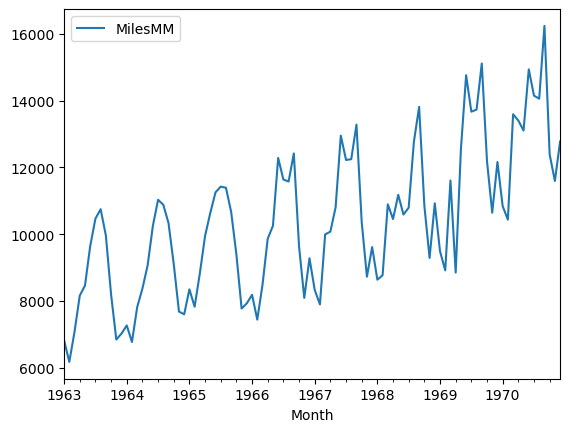

In [62]:
interpolated_miles_df.plot()

In [63]:
poly_interpolated_miles_df = upsampled_miles_df.interpolate(method='spline', order=2)
poly_interpolated_miles_df.head(32) 

,MilesMM
Month,
1963-01-31,6827.0
1963-02-28,6178.0
1963-03-31,7084.0
1963-04-30,8162.0
1963-05-31,8462.0
1963-06-30,9644.0
1963-07-31,10466.0
1963-08-31,10748.0
1963-09-30,9963.0


<Axes: xlabel='Month'>

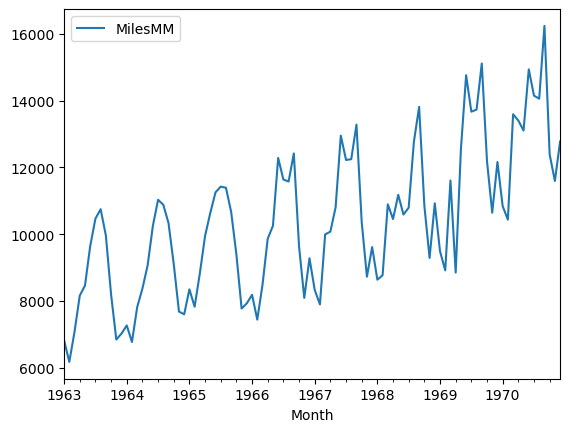

In [64]:

poly_interpolated_miles_df.plot()